# Notebook 3 — Quantum Eve: Shor's algorithm on IBM Quantum

Eve now has access to a quantum computer. She is going to use **Shor's algorithm** — a polynomial-time quantum algorithm for integer factorisation — to break the same RSA ciphertext from Notebook 1.

**What this notebook does**
1. Builds a complete, end-to-end Shor's-algorithm circuit for the canonical `N = 15` (same modulus used in Notebooks 1 and 2).
2. Runs that *same* circuit through **two independent execution test cases**:
   - **Test case A — Local noiseless simulation** with `qiskit-aer`. This is the ground-truth baseline.
   - **Test case B — Real IBM Quantum hardware** on one of the 156‑qubit Heron r2 backends (`ibm_kingston`, `ibm_fez`, `ibm_marrakesh`).
3. Recovers the period via continued fractions, derives `p, q`, then `φ(N)`, `d`, and decrypts Alice's ciphertext.
4. Discusses how the procedure does (and does not) scale to real-world RSA moduli.

**Canonical demo values (same as Notebooks 1 and 2):**

| symbol | value |
|--------|-------|
| `N`        | `15` |
| `e`        | `3` |
| `c`        | `2` |
| plaintext (target) | `m = 8` |

> **Why `N = 15` and not a larger RSA modulus?** Today's superconducting devices are noisy. The qubit budget for Shor's at 50+ bits fits a 156‑qubit chip, but the gate-depth budget does not — the compiled circuit would have `>10⁵` two-qubit gates, far beyond NISQ coherence. `N = 15` is the largest semiprime for which Shor's reliably terminates on real hardware. Section 9 discusses the scaling story.

In [1]:
import json
import math
from fractions import Fraction
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.synthesis.qft import synth_qft_full
from qiskit.visualization import plot_histogram, plot_distribution

from sympy import mod_inverse, isprime

%matplotlib inline

## 1. Eve loads the intercepted RSA data

Eve loads the same `(N, e, c)` triple as in Notebook 2. The hardcoded fallback below makes this notebook runnable on its own.

In [ ]:
# Canonical demo values, identical across all three notebooks.
EXPECTED_N = 15
EXPECTED_E = 3
EXPECTED_C = 2
EXPECTED_PLAINTEXT = 8

json_path = Path('rsa_public.json')
if json_path.exists():
    blob = json.loads(json_path.read_text())
    N = blob['N']; e = blob['e']; c = blob['c']
    expected_pt = blob.get('_plaintext_for_verification_only', EXPECTED_PLAINTEXT)
    print(f'loaded public data from {json_path.resolve()}')
else:
    N, e, c = EXPECTED_N, EXPECTED_E, EXPECTED_C
    expected_pt = EXPECTED_PLAINTEXT
    print('rsa_public.json not found - using hardcoded canonical values')

assert (N, e, c) == (EXPECTED_N, EXPECTED_E, EXPECTED_C), \
    'loaded values disagree with the canonical demo values'

n_bits = N.bit_length()
print(f'RSA modulus N  = {N}  ({n_bits} bits)')
print(f'RSA exponent e = {e}')
print(f'ciphertext c   = {c}')
print(f'plaintext m to recover (kept private in real life): {expected_pt}')
print()
print(f'Textbook Shor qubit budget        (3 * n) ~ {3*n_bits}')
print(f"Beauregard's compiled Shor budget (2n+3)  ~ {2*n_bits+3}")
print(f'Heron r2 hardware available               : 156 qubits')

## 2. Shor's algorithm in a nutshell

To factor `N`:

1. Pick `a` with `1 < a < N` and `gcd(a, N) = 1`. (If `gcd ≠ 1`, a factor is already in hand.)
2. Find the **order** `r` of `a` modulo `N`: the smallest `r ≥ 1` with `aʳ ≡ 1 (mod N)`. This is the hard step — and the *only* step that uses a quantum computer.
3. If `r` is odd or `a^(r/2) ≡ −1 (mod N)`, restart with a new `a`. Otherwise the factors are
$$p = \gcd\bigl(a^{r/2} - 1,\, N\bigr), \qquad q = \gcd\bigl(a^{r/2} + 1,\, N\bigr).$$

Step 2 is performed by **quantum phase estimation** on the modular-multiplication unitary `U_a |y⟩ = |a·y mod N⟩`. Measuring the phase register yields an integer `mphase` such that `mphase / 2^t ≈ s / r` for some `s`. **Continued fractions** then recover `r`.

The researcher picks `a = 7` (coprime to 15, expected order `r = 4`).

## 3. Building the compiled Shor circuit for `N = 15`, `a = 7`

For `N = 15` and well-chosen `a ∈ {2, 4, 7, 8, 11, 13}` the modular multiplication unitary is just a small permutation of 4 work qubits — a handful of SWAPs and Xs. This is the standard textbook compilation; see Qiskit's *Shor's algorithm* tutorial.

- Work register: 4 qubits (since `15 < 2⁴`), initialised to `|1⟩`.
- Counting register: `n_count = 4` qubits — enough resolution to resolve the expected period `r = 4` via continued fractions.
- Total: 8 qubits.

In [3]:
def c_amod15(a, power):
    '''Controlled multiplication by a^power mod 15, acting on 4 work qubits.
    Valid a values: 2, 4, 7, 8, 11, 13.'''
    if a not in (2, 4, 7, 8, 11, 13):
        raise ValueError("'a' must be one of 2,4,7,8,11,13")
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in (2, 13):
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        if a in (7, 8):
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        if a in (4, 11):
            U.swap(1, 3); U.swap(0, 2)
        if a in (7, 11, 13):
            for q in range(4):
                U.x(q)
    gate = U.to_gate(label=f'{a}^{power} mod 15')
    return gate.control()


def inverse_qft_gate(n):
    '''Build an inverse-QFT gate on n qubits using the current Qiskit synthesis API.'''
    qft = synth_qft_full(n, do_swaps=True)
    iqft = qft.inverse()
    return iqft.to_gate(label='IQFT')


def shor_circuit_15(a=7, n_count=4):
    '''Full Shor's-algorithm circuit for N=15 with the given base a.'''
    qc = QuantumCircuit(n_count + 4, n_count)
    # 1. Hadamard on the counting register
    for i in range(n_count):
        qc.h(i)
    # 2. Initialise work register to |1>
    qc.x(n_count)
    # 3. Controlled-U^(2^k) for k = 0 .. n_count-1
    for k in range(n_count):
        qc.append(c_amod15(a, 2**k),
                  [k] + list(range(n_count, n_count + 4)))
    # 4. Inverse QFT on the counting register
    qc.append(inverse_qft_gate(n_count), range(n_count))
    # 5. Measure the counting register
    qc.measure(range(n_count), range(n_count))
    return qc


a_demo, n_count = 7, 4
qc_shor = shor_circuit_15(a=a_demo, n_count=n_count)
print(f'circuit width : {qc_shor.num_qubits} qubits')
print(f'circuit depth : {qc_shor.depth()}')

circuit width : 8 qubits
circuit depth : 7


### 3a. Visualising the top-level circuit

Each rectangular block hides a sub-circuit: the controlled modular-multiplication gates `7^{2^k} mod 15` and the inverse QFT. The decomposed views in Section 3b open them up.

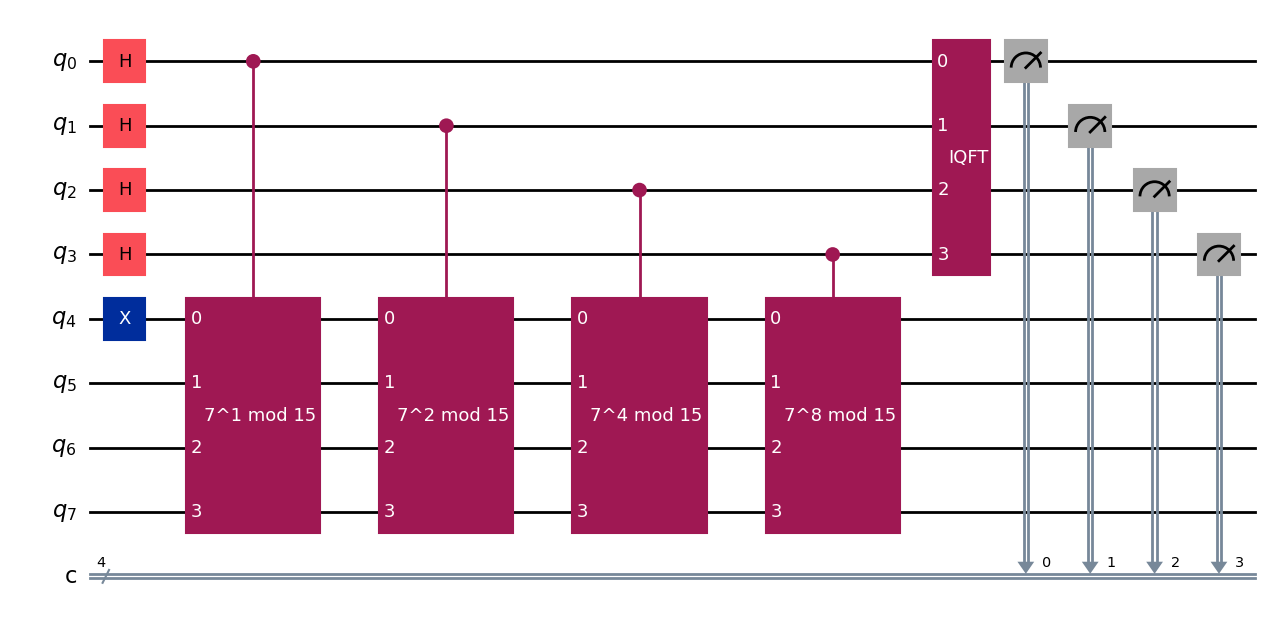

In [4]:
fig_top = qc_shor.draw('mpl', fold=120)
plt.close(fig_top)
fig_top

### 3b. Visualising the inverse-QFT and modular-multiplication sub-circuits separately

These two building blocks are the heart of Shor's algorithm — the inverse QFT performs the phase estimation, and the controlled modular multipliers compute the function whose period is being measured.

Inverse Quantum Fourier Transform on the 4-qubit counting register:


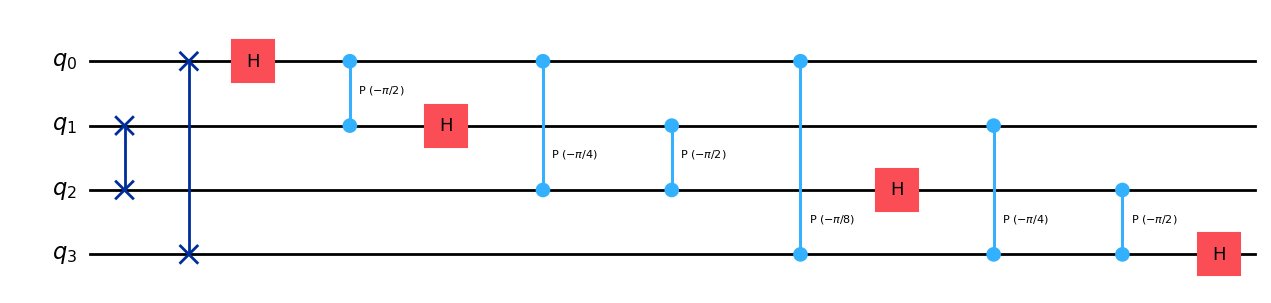

In [5]:
iqft = synth_qft_full(n_count, do_swaps=True).inverse()
iqft.name = 'IQFT'
print('Inverse Quantum Fourier Transform on the 4-qubit counting register:')
fig_iqft = iqft.draw('mpl')
plt.close(fig_iqft)
fig_iqft

Modular multiplication by 7 mod 15 (acts on the 4-qubit work register):


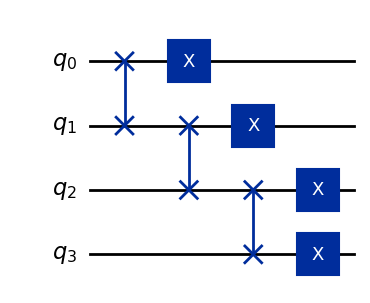

In [6]:
u_mult = QuantumCircuit(4, name='U: |y> -> |7 y mod 15>')
u_mult.swap(0, 1); u_mult.swap(1, 2); u_mult.swap(2, 3)
for q in range(4):
    u_mult.x(q)
print('Modular multiplication by 7 mod 15 (acts on the 4-qubit work register):')
fig_u = u_mult.draw('mpl')
plt.close(fig_u)
fig_u

## 4. Classical post-processing: continued fractions → period → factors

Whatever counts come back from a sampler — simulator or hardware — the same classical routine extracts a period and tries to derive factors:

- For each measurement integer `mphase`, form `phase = mphase / 2^n_count`.
- Use continued fractions to approximate `phase` by a rational `s/r` with `r ≤ N`. That denominator `r` is the candidate period.
- Apply Shor's classical reduction: factors are `gcd(a^{r/2} ± 1, N)`.

The helper `recover_factors_from_counts` walks the most frequent measurements and returns the first one that yields a non-trivial factoring. The two test cases below (simulator and hardware) both feed their counts into this same helper.

In [7]:
def measurement_to_period(measured_int, n_count, N):
    '''Use continued fractions to extract candidate period r from a measurement.'''
    if measured_int == 0:
        return None
    phase = measured_int / (2 ** n_count)
    frac = Fraction(phase).limit_denominator(N)
    return frac.denominator


def factors_from_period(a, r, N):
    '''Apply Shor's classical reduction. Returns (p, q) or None.'''
    if r is None or r % 2 != 0:
        return None
    x = pow(a, r // 2, N)
    if x == N - 1:
        return None
    p = math.gcd(x - 1, N)
    q = math.gcd(x + 1, N)
    if 1 < p < N and 1 < q < N and p * q == N:
        return (p, q)
    if 1 < p < N and N % p == 0:
        return (p, N // p)
    if 1 < q < N and N % q == 0:
        return (q, N // q)
    return None


def recover_factors_from_counts(counts, a, n_count, N, top_k=8, label=''):
    '''Try the most-frequent measurements first, return the first non-trivial factoring.'''
    prefix = f'[{label}] ' if label else ''
    ranked = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    for bitstring, freq in ranked[:top_k]:
        measured = int(bitstring, 2)
        r = measurement_to_period(measured, n_count, N)
        factors = factors_from_period(a, r, N) if r else None
        print(f'{prefix}measured = {measured:>3}   bit = {bitstring}   freq = {freq:>5}   r = {r}   factors = {factors}')
        if factors:
            return factors
    return None

## 5. Test case A — Local noiseless simulation (`qiskit-aer`)

**Purpose.** Establish the ground truth: what the circuit *should* produce in the absence of noise. Any deviation in test case B (hardware) below is then attributable to physical errors rather than a circuit-construction bug.

**Setup.** A local `AerSimulator` runs the unmodified circuit with 4096 shots. The Aer transpiler is allowed to use whatever basis it likes (this run does *not* target hardware connectivity).

[Test case A: simulator] top 8 measurement outcomes:
  1000  ( 8)  -> 1050
  0000  ( 0)  -> 1019
  0100  ( 4)  -> 1017
  1100  (12)  -> 1010


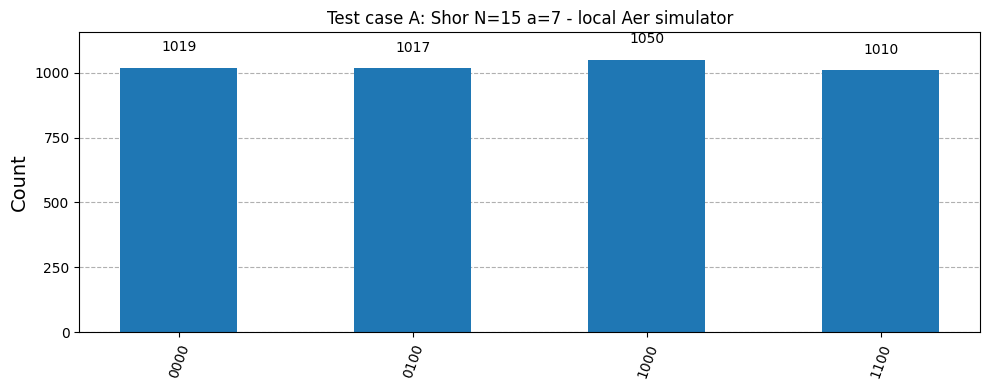

In [8]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc_sim = transpile(qc_shor, sim)
sim_counts = sim.run(qc_sim, shots=4096).result().get_counts()

print('[Test case A: simulator] top 8 measurement outcomes:')
for bitstring, freq in sorted(sim_counts.items(), key=lambda kv: -kv[1])[:8]:
    print(f'  {bitstring}  ({int(bitstring,2):>2})  -> {freq}')

fig_sim = plot_histogram(sim_counts, figsize=(10, 4),
                         title='Test case A: Shor N=15 a=7 - local Aer simulator')
plt.close(fig_sim)
fig_sim

In [9]:
print('[Test case A: simulator] classical post-processing:')
factors_sim = recover_factors_from_counts(sim_counts, a=a_demo, n_count=n_count, N=N, label='SIM')
print(f'\nFactors recovered from simulator: {factors_sim}')
assert factors_sim is not None and sorted(factors_sim) == [3, 5], \
    'simulator failed - circuit construction bug'

[Test case A: simulator] classical post-processing:
[SIM] measured =   8   bit = 1000   freq =  1050   r = 2   factors = (3, 5)

Factors recovered from simulator: (3, 5)


Peaks at `0000`, `0100`, `1000`, `1100` (`mphase = 0, 4, 8, 12`) → `phase ≈ s/4` → period `r = 4` → factors `{3, 5}`. ✅ Test case A passes; the circuit is mathematically correct.

## 6. Connect to IBM Quantum

Authentication uses `QiskitRuntimeService`. The API token below is the one provided for this experiment — in production it should be stored via `QiskitRuntimeService.save_account(...)` instead of pasted into a notebook.

The connection tries the new unified IBM Quantum Platform channel first and falls back to legacy channels if necessary. The next cell then probes each of the three 156‑qubit Heron r2 backends and selects the one with the shortest queue.

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService

IBM_TOKEN = 'XXXXX'

service = None
for channel in ('ibm_quantum_platform', 'ibm_cloud', 'ibm_quantum'):
    try:
        service = QiskitRuntimeService(channel=channel, token=IBM_TOKEN)
        print(f'authenticated on channel: {channel}')
        break
    except Exception as exc:
        print(f'channel {channel}: {exc.__class__.__name__}: {exc}')

if service is None:
    raise RuntimeError('Could not authenticate to IBM Quantum with the provided token.')

qiskit_runtime_service._discover_account:WARNING:2026-05-17 10:06:54,651: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-17 10:07:19,721: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


authenticated on channel: ibm_quantum_platform


In [11]:
candidates = ['ibm_kingston', 'ibm_fez', 'ibm_marrakesh']

available = []
for name in candidates:
    try:
        b = service.backend(name)
        status = b.status()
        available.append((name, b, status.pending_jobs, status.operational))
        print(f'{name:18s}  qubits={b.num_qubits:3d}  pending_jobs={status.pending_jobs:>4}  operational={status.operational}')
    except Exception as exc:
        print(f'{name:18s}  unavailable: {exc}')

available = [a for a in available if a[3]]
assert available, 'no operational Heron r2 backend is reachable with this account'
available.sort(key=lambda x: x[2])
backend_name, backend, queue_len, _ = available[0]
print(f'\n-> selected backend: {backend_name} (queue {queue_len})')

qiskit_runtime_service.backends:WARNING:2026-05-17 10:07:19,729: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-17 10:07:24,874: Using instance: open-instance, plan: open


ibm_kingston        qubits=156  pending_jobs=   0  operational=True


qiskit_runtime_service.backends:WARNING:2026-05-17 10:07:29,816: Using instance: open-instance, plan: open


ibm_fez             qubits=156  pending_jobs=   0  operational=True
ibm_marrakesh       qubits=156  pending_jobs=   0  operational=True

-> selected backend: ibm_kingston (queue 0)


## 7. Test case B — Real IBM Quantum hardware (Heron r2, 156 qubits)

**Purpose.** Verify that the *same* circuit that worked in test case A still yields the correct period on physical hardware, despite gate-, readout-, and decoherence noise.

**Setup.** The circuit is transpiled to the chosen backend's native gate set and topology (`optimization_level=3`), then submitted through `SamplerV2`, the current runtime primitive for sampling measurement distributions. The job blocks until execution finishes (queue + run; typically a few minutes).

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

qc_hw = transpile(qc_shor, backend=backend, optimization_level=3)
print(f'[Test case B: hardware] transpiled circuit: {qc_hw.num_qubits} qubits, depth {qc_hw.depth()}')
print(f'[Test case B: hardware] gate counts: {dict(qc_hw.count_ops())}')

sampler = Sampler(mode=backend)
shots   = 4096
job     = sampler.run([qc_hw], shots=shots)
print(f'\nsubmitted job id: {job.job_id()}')
print('Monitor it at https://quantum.ibm.com/jobs or by re-running the next cell.')

[Test case B: hardware] transpiled circuit: 156 qubits, depth 4021
[Test case B: hardware] gate counts: {'sx': 2936, 'rz': 1953, 'cz': 1463, 'x': 37, 'measure': 4}

submitted job id: d84i5pvtjchs73bqa61g
Monitor it at https://quantum.ibm.com/jobs or by re-running the next cell.


In [13]:
print(f'[Test case B: hardware] current status: {job.status()}')
result = job.result()                  # blocks until done
print(f'[Test case B: hardware] final status:   {job.status()}')

[Test case B: hardware] current status: QUEUED
[Test case B: hardware] final status:   DONE


[Test case B: hardware] classical register name: 'c'
[Test case B: hardware] top 8 measurement outcomes:
  1111  (15)  -> 389
  1010  (10)  -> 363
  0111  ( 7)  -> 344
  0010  ( 2)  -> 339
  1000  ( 8)  -> 335
  0000  ( 0)  -> 302
  1011  (11)  -> 294
  0011  ( 3)  -> 273


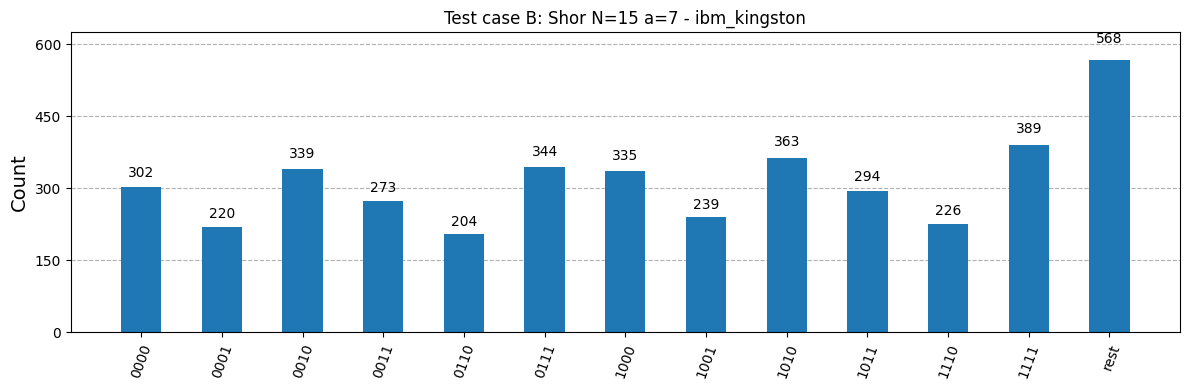

In [14]:
pub_result = result[0]
data_bin = pub_result.data
creg_name = next(iter(data_bin.keys()))      # e.g. 'c' or 'meas'
hw_counts = getattr(data_bin, creg_name).get_counts()

print(f'[Test case B: hardware] classical register name: {creg_name!r}')
print('[Test case B: hardware] top 8 measurement outcomes:')
for bitstring, freq in sorted(hw_counts.items(), key=lambda kv: -kv[1])[:8]:
    print(f'  {bitstring}  ({int(bitstring,2):>2})  -> {freq}')

fig_hw = plot_histogram(hw_counts, figsize=(12, 4),
                        title=f'Test case B: Shor N=15 a=7 - {backend_name}',
                        number_to_keep=12)
plt.close(fig_hw)
fig_hw

## 8. Side-by-side comparison of test cases A and B

Both distributions should peak at `mphase ∈ {0, 4, 8, 12}` (the binary strings `0000`, `0100`, `1000`, `1100`). The simulator places ~100% of its mass on these four bins; the hardware spreads some mass into noisy neighbours but the four good bins should still dominate.

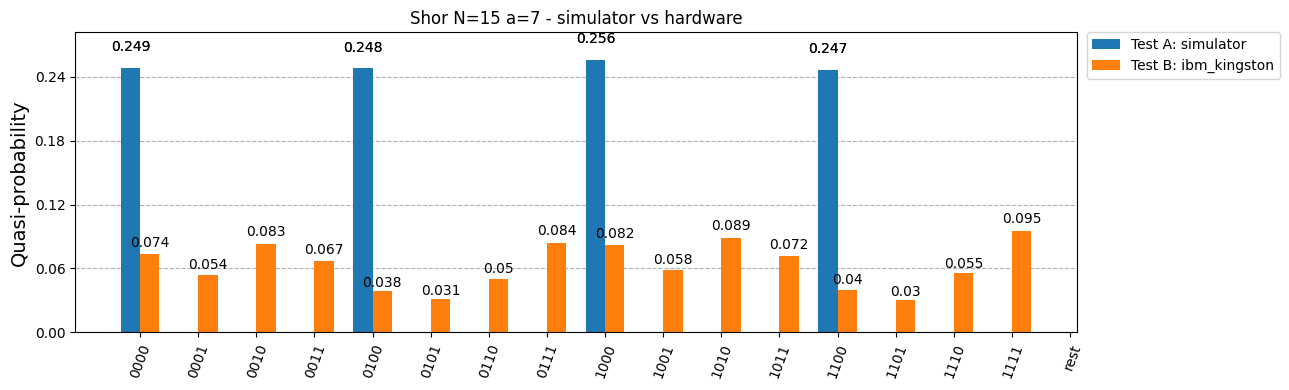

In [15]:
def _normalise(counts):
    total = sum(counts.values()) or 1
    return {k: v / total for k, v in counts.items()}

sim_dist = _normalise(sim_counts)
hw_dist  = _normalise(hw_counts)

fig_cmp = plot_distribution([sim_dist, hw_dist],
                            legend=['Test A: simulator',
                                    f'Test B: {backend_name}'],
                            title='Shor N=15 a=7 - simulator vs hardware',
                            figsize=(13, 4),
                            number_to_keep=16)
plt.close(fig_cmp)
fig_cmp

## 9. Recover the factors from the hardware result and decrypt

The top hardware measurements are now fed into the same `recover_factors_from_counts` helper that test case A used. With the factors in hand, the rest of the attack is identical to Notebook 2: compute `φ(N)`, recover `d`, decrypt `c → m`.

In [16]:
print('[Test case B: hardware] classical post-processing:')
factors_hw = recover_factors_from_counts(hw_counts, a=a_demo, n_count=n_count, N=N, top_k=12, label='HW')
print(f'\nFactors of {N} recovered from {backend_name}: {factors_hw}')

assert factors_hw is not None, (
    'Hardware noise was too high to recover a valid period from the top measurements. '
    'Re-running the job (more shots, or a different backend) usually fixes this.'
)
p_q, q_q = sorted(factors_hw)
assert (p_q, q_q) == (3, 5)

phi_q = (p_q - 1) * (q_q - 1)
d_q   = int(mod_inverse(e, phi_q))
m_q   = pow(c, d_q, N)

print(f'\nfactors                 : p = {p_q}, q = {q_q}  (from quantum hardware!)')
print(f'reconstructed phi(N)    : {phi_q}')
print(f'reconstructed private d : {d_q}')
print(f'decrypted m             : c^d mod N = {c}^{d_q} mod {N} = {m_q}')

# Pin against the canonical values from Notebook 1.
assert phi_q == 8 and d_q == 3 and m_q == expected_pt == 8
print("\nQuantum Eve wins - Alice's secret integer recovered from a real quantum chip.")

[Test case B: hardware] classical post-processing:
[HW] measured =  15   bit = 1111   freq =   389   r = 15   factors = None
[HW] measured =  10   bit = 1010   freq =   363   r = 8   factors = None
[HW] measured =   7   bit = 0111   freq =   344   r = 9   factors = None
[HW] measured =   2   bit = 0010   freq =   339   r = 8   factors = None
[HW] measured =   8   bit = 1000   freq =   335   r = 2   factors = (3, 5)

Factors of 15 recovered from ibm_kingston: (3, 5)

factors                 : p = 3, q = 5  (from quantum hardware!)
reconstructed phi(N)    : 8
reconstructed private d : 3
decrypted m             : c^d mod N = 2^3 mod 15 = 8

Quantum Eve wins - Alice's secret integer recovered from a real quantum chip.


## 10. Why this is significant — and the catch

**What just happened.** A real superconducting quantum processor returned measurement statistics from which the researcher extracted the period of `7 mod 15`, used that period to factor `15`, reconstructed the private RSA exponent, and decrypted Alice's ciphertext. *Nowhere in the attack did the quantum computer see `p`, `q`, `φ(N)` or `d`* — it only sees `N` and `a`.

**Qubit budget.** Beauregard's compiled Shor's algorithm needs `2n + 3` qubits to factor an `n`-bit integer. RSA‑2048 is `n = 2048`, so the qubit budget is `4099` — *not* in reach today, but a clearly defined target. The 156‑qubit `ibm_kingston / ibm_fez / ibm_marrakesh` devices already easily host the algorithm for any modulus up to about 76 bits.

**Gate-depth budget.** This is where current hardware loses. The order-finding circuit needs `O(n³)` two-qubit gates. At `n = 4` (this demo) that is ~64 gates — well within coherence. At `n = 2048` it is ~10¹⁰ gates and absolutely requires fault-tolerant quantum error correction, which adds a factor of ~1000× in physical qubits per logical qubit.

**Bottom line.** RSA is **mathematically broken** by Shor's algorithm; only engineering keeps it alive. Post‑quantum cryptography (Kyber, Dilithium, …) is the migration path — switch *before* a sufficiently large QEC-enabled machine exists, because anything encrypted today can be archived and decrypted later.

### What the researcher has just demonstrated, end-to-end
- *Notebook 1*: RSA encryption with `N = 15`, `e = 3`, plaintext `m = 8`, ciphertext `c = 2`.
- *Notebook 2*: Two classical factoring test cases (trial division and Pollard's ρ) both crack the same `(N=15, e=3, c=2)` in microseconds; both algorithms scale sub-exponentially and die for real key sizes.
- *Notebook 3*: Two quantum execution test cases — local noiseless simulation (ground truth) and a real IBM Heron r2 hardware run — both factor `15` via period finding and recover the same `m = 8`.